<div style="background:linear-gradient(135deg,#1a1a30 0%,#2a2a3e 100%);border:1px solid #6C63FF;border-radius:10px;padding:28px 30px;margin:10px 0 20px 0;font-family:'Segoe UI',sans-serif;text-align:center;">
  <h1 style="margin:0;font-size:26px;color:#e0e0f0;font-weight:800;letter-spacing:0.5px;">Generation de donnees synthetiques — GANs</h1>
  <p style="margin:8px 0 0 0;font-size:14px;color:#b0b0cc;">CTGAN et TVAE appliques au dataset malware / goodware.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">CTGAN — GOODWARE</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Generation de faux goodwares</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement du modele CTGAN sur les echantillons goodware (Label = 0).</p>
</div>


In [9]:
from ctgan import CTGAN
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
#import de dataset clean
df=pd.read_csv("dataset_clean.csv")
# Good
df_good = df[df["Label"] == 0]
df_good = df_good.drop("Label", axis=1)
discrete_columns = ["Label"]

#Goodware
ctgan_g = CTGAN(epochs=300) #train
ctgan_g.fit(df_good)
fake_good = ctgan_g.sample(200)
# enlever négatifs
fake_good = fake_good.clip(lower=0)
# arrondir
fake_good = fake_good.round()
fake_good["Label"] = 0
fake_good.head()

,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,GetFileInformationByHandleEx,...,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile,Label
0,0,0.0,17,0.0,21.0,0.0,41,390.0,0,0.0,...,2.0,219.0,0.0,17.0,27.0,0,0.0,0,0,0
1,0,0.0,26,6.0,0.0,3.0,17,0.0,0,0.0,...,35.0,168.0,0.0,1660.0,2.0,2,68.0,0,0,0
2,0,0.0,50,0.0,36.0,0.0,20,670.0,0,18.0,...,0.0,4279.0,0.0,0.0,22.0,3,71.0,0,0,0
3,0,0.0,0,0.0,0.0,0.0,13,0.0,0,0.0,...,1.0,258.0,15.0,1494.0,0.0,1,133.0,0,0,0
4,0,0.0,292,0.0,0.0,0.0,22,310.0,0,32.0,...,17.0,5216.0,0.0,49.0,30.0,21,0.0,0,0,0


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">CTGAN — RANSOMWARE</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Generation de faux ransomwares</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement du modele CTGAN sur les echantillons ransomware (Label = 1).</p>
</div>


In [10]:
# Ransom
df_ransom = df[df["Label"] == 1]
df_ransom = df_ransom.drop("Label", axis=1)
discrete_columns = ["Label"]

#Ransomware
ctgan_r = CTGAN(epochs=300) #train
ctgan_r.fit(df_ransom)
fake_ransom = ctgan_r.sample(200)
# enlever négatifs
fake_ransom = fake_ransom.clip(lower=0)
# arrondir
fake_ransom = fake_ransom.round()
fake_ransom["Label"] = 1
fake_ransom.head()

,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,GetFileInformationByHandleEx,...,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile,Label
0,0,0.0,0,10.0,0.0,395.0,0,0.0,0,1.0,...,0.0,0.0,262.0,0.0,0.0,6,0.0,0,0,1
1,0,0.0,0,16.0,0.0,2503.0,0,0.0,0,1.0,...,7.0,0.0,0.0,36.0,0.0,4,97.0,0,0,1
2,0,0.0,0,14.0,0.0,0.0,0,10.0,13,0.0,...,0.0,1615.0,0.0,0.0,0.0,0,59.0,0,0,1
3,0,0.0,0,11.0,0.0,243.0,0,0.0,0,0.0,...,0.0,0.0,8.0,0.0,0.0,3,102.0,0,0,1
4,0,0.0,0,1.0,0.0,311.0,15,5578.0,0,2.0,...,3.0,0.0,0.0,0.0,0.0,0,177.0,0,0,1


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">CTGAN — FUSION</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Construction du dataframe synthetique CTGAN</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Concatenation des donnees goodware et ransomware generees par CTGAN.</p>
</div>


In [11]:
ctgan_df=pd.concat([fake_good,fake_ransom])
ctgan_df=ctgan_df[df.columns]#pour rendre la colonne label la premier colonne
ctgan_df.head()

,Label,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,...,SUMMARY_FILE_CREATED,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile
0,0,0,0.0,17,0.0,21.0,0.0,41,390.0,0,...,31.0,2.0,219.0,0.0,17.0,27.0,0,0.0,0,0
1,0,0,0.0,26,6.0,0.0,3.0,17,0.0,0,...,0.0,35.0,168.0,0.0,1660.0,2.0,2,68.0,0,0
2,0,0,0.0,50,0.0,36.0,0.0,20,670.0,0,...,130.0,0.0,4279.0,0.0,0.0,22.0,3,71.0,0,0
3,0,0,0.0,0,0.0,0.0,0.0,13,0.0,0,...,77.0,1.0,258.0,15.0,1494.0,0.0,1,133.0,0,0
4,0,0,0.0,292,0.0,0.0,0.0,22,310.0,0,...,586.0,17.0,5216.0,0.0,49.0,30.0,21,0.0,0,0


<div style="background:linear-gradient(90deg,#2a2a3e 0%,#1a1a30 100%);border-left:6px solid #6C63FF;border-radius:7px;padding:20px 24px;margin:20px 0 12px 0;font-family:'Segoe UI',sans-serif;">
  <h2 style="margin:0;font-size:22px;color:#e0e0f0;font-weight:800;letter-spacing:0.4px;">TVAE — Variational Autoencoder Tabular</h2>
  <p style="margin:6px 0 0 0;font-size:13px;color:#b0b0cc;">Alternative a CTGAN basee sur un autoencodeur variationnel.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">TVAE — GOODWARE</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Generation de faux goodwares</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement du modele TVAE sur les echantillons goodware (Label = 0).</p>
</div>


In [12]:
from ctgan import TVAE
df=pd.read_csv("dataset_clean.csv")

# Good
df_good = df[df["Label"] == 0]
df_good = df_good.drop("Label", axis=1)
discrete_columns = ["Label"]

# Goodware
tvae_g = TVAE(epochs=300) #train
tvae_g.fit(df_good)
fake_good = tvae_g.sample(200)
# enlever négatifs
fake_good = fake_good.clip(lower=0)
# arrondir
fake_good = fake_good.round()
fake_good["Label"] = 0
fake_good.head()

,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,GetFileInformationByHandleEx,...,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile,Label
0,0,0.0,8,0.0,0.0,54.0,8,116.0,0,2.0,...,1.0,21.0,12.0,30.0,0.0,1,0.0,0,0,0
1,0,0.0,0,1.0,2.0,48.0,3,1.0,0,1.0,...,1.0,123.0,6.0,95.0,8.0,1,53.0,0,0,0
2,0,0.0,0,0.0,0.0,16.0,11,178.0,0,5.0,...,1.0,33.0,0.0,82.0,5.0,0,10.0,0,0,0
3,0,0.0,3,3.0,0.0,15.0,0,0.0,0,0.0,...,0.0,65.0,14.0,0.0,20.0,0,51.0,0,0,0
4,0,0.0,13,24.0,19.0,9.0,6,164.0,2,39.0,...,26.0,80.0,13.0,139.0,61.0,1,0.0,0,0,0


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">TVAE — RANSOMWARE</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Generation de faux ransomwares</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Entrainement du modele TVAE sur les echantillons ransomware (Label = 1).</p>
</div>


In [13]:
from ctgan import TVAE
df=pd.read_csv("dataset_clean.csv")

# Ransom
df_ransom = df[df["Label"] == 1]
df_ransom = df_ransom.drop("Label", axis=1)
discrete_columns = ["Label"]

# Ransomware
tvae_r = TVAE(epochs=300) # Train
tvae_r.fit(df_ransom)
fake_ransom = tvae_r.sample(200)
# enlever négatifs
fake_ransom = fake_ransom.clip(lower=0)
# arrondir
fake_ransom = fake_ransom.round()
fake_ransom["Label"] = 1
fake_ransom.head()

,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,GetFileInformationByHandleEx,...,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile,Label
0,0,0.0,0,9.0,1.0,15.0,0,0.0,0,0.0,...,2.0,30.0,0.0,77.0,4.0,1,0.0,0,0,1
1,0,0.0,0,4.0,5.0,93.0,7,7.0,0,1.0,...,2.0,17.0,15.0,113.0,0.0,0,0.0,0,0,1
2,0,0.0,0,4.0,4.0,162.0,5,0.0,0,1.0,...,5.0,0.0,19.0,15.0,0.0,0,0.0,0,0,1
3,0,0.0,0,0.0,4.0,0.0,0,125.0,0,0.0,...,5.0,38.0,5.0,0.0,0.0,2,0.0,0,0,1
4,0,0.0,0,2.0,3.0,0.0,7,0.0,0,1.0,...,0.0,0.0,4.0,36.0,17.0,1,18.0,0,0,1


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">TVAE — FUSION</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Construction du dataframe synthetique TVAE</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Concatenation des donnees goodware et ransomware generees par TVAE.</p>
</div>


In [14]:
tvae_df=pd.concat([fake_good,fake_ransom])
tvae_df=tvae_df[df.columns]
tvae_df.head()

,Label,CopyFileA,CopyFileW,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,...,SUMMARY_FILE_CREATED,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN,URLDownloadToFileW,NtQueryFullAttributesFile
0,0,0,0.0,8,0.0,0.0,54.0,8,116.0,0,...,40.0,1.0,21.0,12.0,30.0,0.0,1,0.0,0,0
1,0,0,0.0,0,1.0,2.0,48.0,3,1.0,0,...,36.0,1.0,123.0,6.0,95.0,8.0,1,53.0,0,0
2,0,0,0.0,0,0.0,0.0,16.0,11,178.0,0,...,11.0,1.0,33.0,0.0,82.0,5.0,0,10.0,0,0
3,0,0,0.0,3,3.0,0.0,15.0,0,0.0,0,...,31.0,0.0,65.0,14.0,0.0,20.0,0,51.0,0,0
4,0,0,0.0,13,24.0,19.0,9.0,6,164.0,2,...,7.0,26.0,80.0,13.0,139.0,61.0,1,0.0,0,0


<div style="background:linear-gradient(90deg,#2a2a3e 0%,#1a1a30 100%);border-left:6px solid #6C63FF;border-radius:7px;padding:20px 24px;margin:20px 0 12px 0;font-family:'Segoe UI',sans-serif;">
  <h2 style="margin:0;font-size:22px;color:#e0e0f0;font-weight:800;letter-spacing:0.4px;">Sauvegarde des datasets synthetiques</h2>
  <p style="margin:6px 0 0 0;font-size:13px;color:#b0b0cc;">Export des dataframes CTGAN et TVAE au format CSV.</p>
</div>


In [15]:
ctgan_df.to_csv("ctgan_synthetic.csv",index=False)
tvae_df.to_csv("tvae_synthetic.csv",index=False)

<div style="background:linear-gradient(90deg,#2a2a3e 0%,#1a1a30 100%);border-left:6px solid #6C63FF;border-radius:7px;padding:20px 24px;margin:20px 0 12px 0;font-family:'Segoe UI',sans-serif;">
  <h2 style="margin:0;font-size:22px;color:#e0e0f0;font-weight:800;letter-spacing:0.4px;">Comparaison — Reel vs CTGAN vs TVAE</h2>
  <p style="margin:6px 0 0 0;font-size:13px;color:#b0b0cc;">Verification visuelle que les distributions synthetiques restent proches du dataset original.</p>
</div>


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">CHARGEMENT</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Chargement des trois datasets</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">dataset_clean.csv, ctgan_synthetic.csv, tvae_synthetic.csv.</p>
</div>


In [19]:
# ---- Chargement des datasets pour comparaison ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

real_df  = pd.read_csv('dataset_clean.csv')
ctgan_df = pd.read_csv('ctgan_synthetic.csv')
tvae_df  = pd.read_csv('tvae_synthetic.csv')

# style global
DARK_BG = '#1e1e2e'
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': DARK_BG,
    'text.color': 'white',       'axes.labelcolor': 'white',
    'xtick.color': 'white',       'ytick.color': 'white',
    'axes.titlecolor': 'white',   'axes.edgecolor': '#444',
    'grid.color': '#333',
})
CLR_REAL  = '#6C63FF'   # violet  → reel
CLR_CTGAN = '#FF6584'   # rose    → CTGAN
CLR_TVAE  = '#43C59E'   # vert    → TVAE
handles = [
    mpatches.Patch(color=CLR_REAL,  label='Reel'),
    mpatches.Patch(color=CLR_CTGAN, label='CTGAN'),
    mpatches.Patch(color=CLR_TVAE,  label='TVAE'),
]
TOP_FEATS = [
    'GetFileAttributesW', 'FindFirstFileExW', 'SUMMARY_FILE_READ',
    'SUMMARY_FILE_EXISTS', 'DeleteFileW',     'CreateDirectoryW',
]
print('Real :', real_df.shape, '| CTGAN :', ctgan_df.shape, '| TVAE :', tvae_df.shape)


Real : (588, 59) | CTGAN : (400, 59) | TVAE : (400, 59)


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">VIZ 1</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Distribution des classes</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Nombre de goodwares et ransomwares dans chaque dataset.</p>
</div>


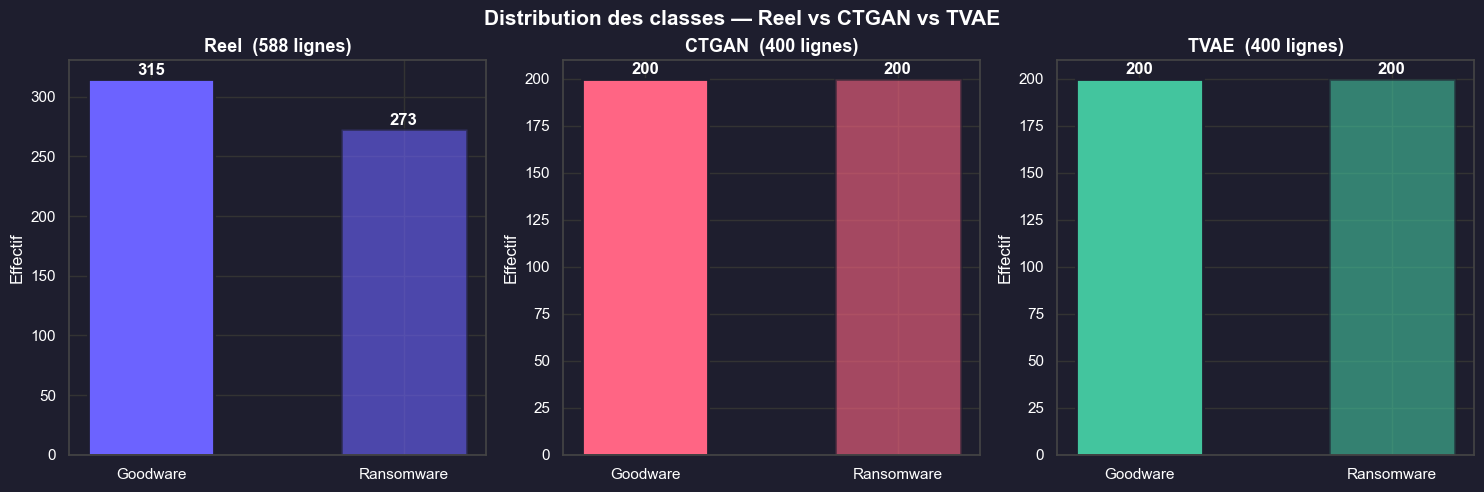

In [25]:
datasets = {'Reel': real_df, 'CTGAN': ctgan_df, 'TVAE': tvae_df}
colors   = [CLR_REAL, CLR_CTGAN, CLR_TVAE]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(DARK_BG)

for ax, (name, df_), color in zip(axes, datasets.items(), colors):
    counts = df_['Label'].value_counts().reindex([0, 1], fill_value=0)
    bars = ax.bar(['Goodware', 'Ransomware'], counts.values,
                  color=[color, color],
                  edgecolor=DARK_BG, linewidth=2, width=0.5)
    bars[1].set_alpha(0.6)  # ✅ alpha appliqué après

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom',
                color='white', fontsize=12, fontweight='bold')

    ax.set_title(f'{name}  ({len(df_)} lignes)', fontsize=13, fontweight='bold')
    ax.set_facecolor(DARK_BG)
    ax.set_ylabel('Effectif')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

plt.suptitle('Distribution des classes — Reel vs CTGAN vs TVAE',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88)  # ✅ suptitle visible
plt.show()

<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">VIZ 2</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Distributions des features (overlay)</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Histogrammes superposes des 6 features les plus importantes.</p>
</div>


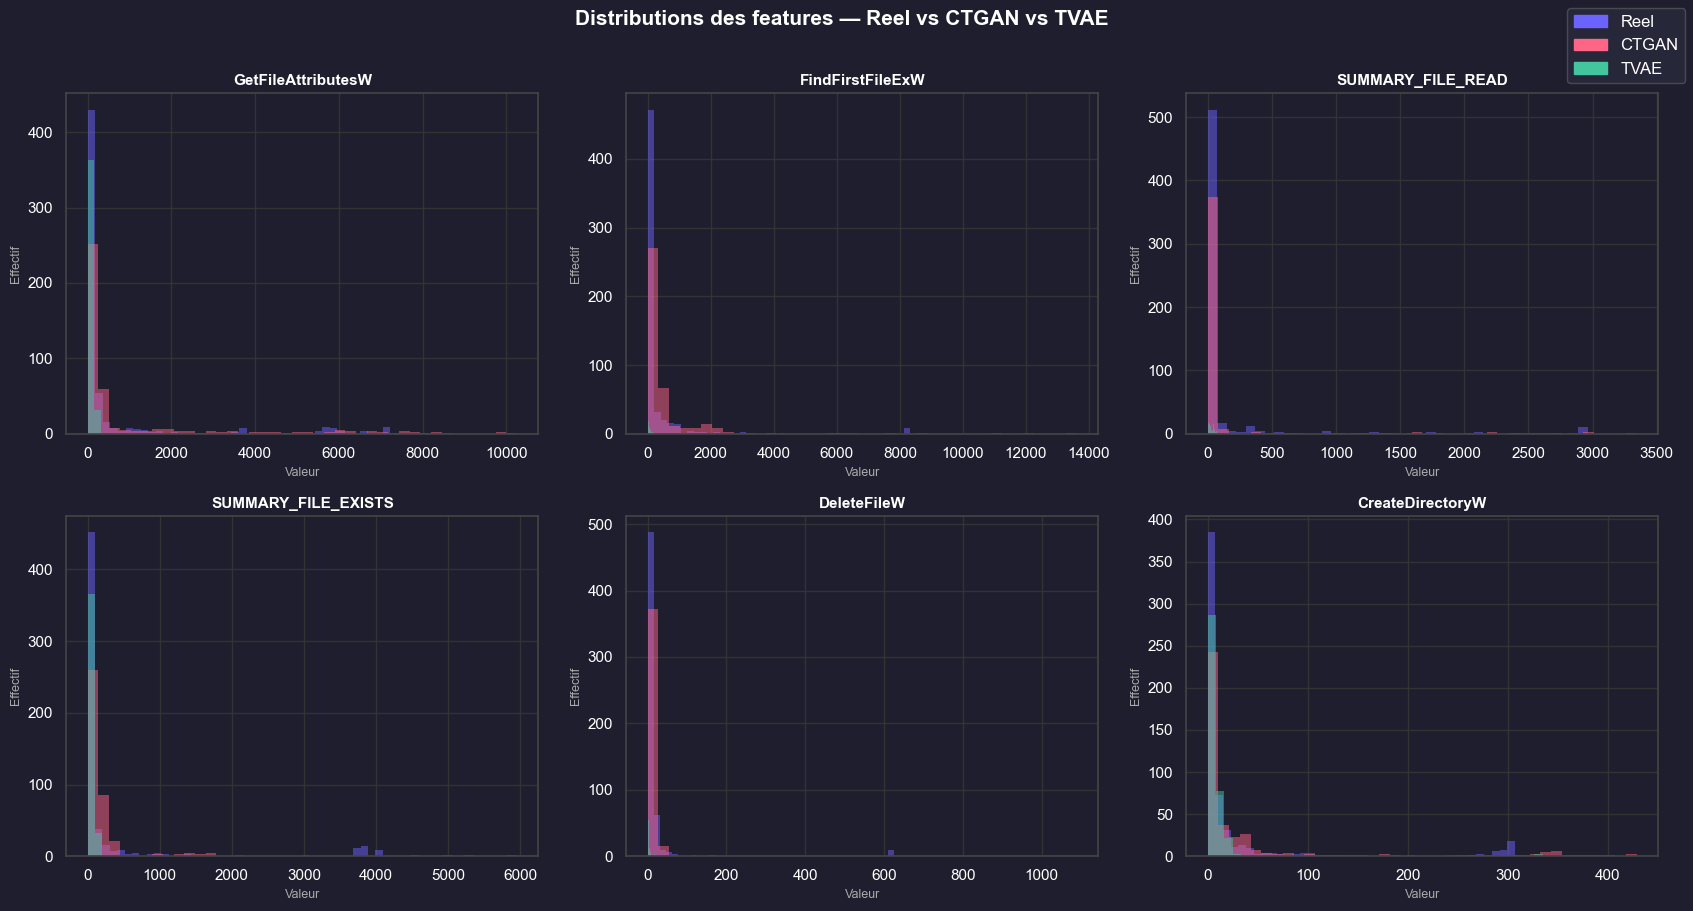

In [21]:
# ---- 2. Distributions des features (overlay) ----
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.patch.set_facecolor(DARK_BG)
axes = axes.flatten()

for ax, feat in zip(axes, TOP_FEATS):
    for df_, color, lbl in [
        (real_df,  CLR_REAL,  'Reel'),
        (ctgan_df, CLR_CTGAN, 'CTGAN'),
        (tvae_df,  CLR_TVAE,  'TVAE'),
    ]:
        ax.hist(df_[feat].dropna(), bins=40,
                color=color, alpha=0.50, edgecolor='none', label=lbl)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_facecolor(DARK_BG)
    ax.tick_params(colors='white')
    ax.set_xlabel('Valeur', color='#aaa', fontsize=9)
    ax.set_ylabel('Effectif', color='#aaa', fontsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#444')

fig.legend(handles=handles, loc='upper right', fontsize=12,
           facecolor='#2a2a3e', edgecolor='#555', labelcolor='white')
plt.suptitle('Distributions des features — Reel vs CTGAN vs TVAE',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">VIZ 3</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Ecart de moyennes par feature</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">15 features avec le plus grand ecart de moyenne entre reel et synthetique.</p>
</div>


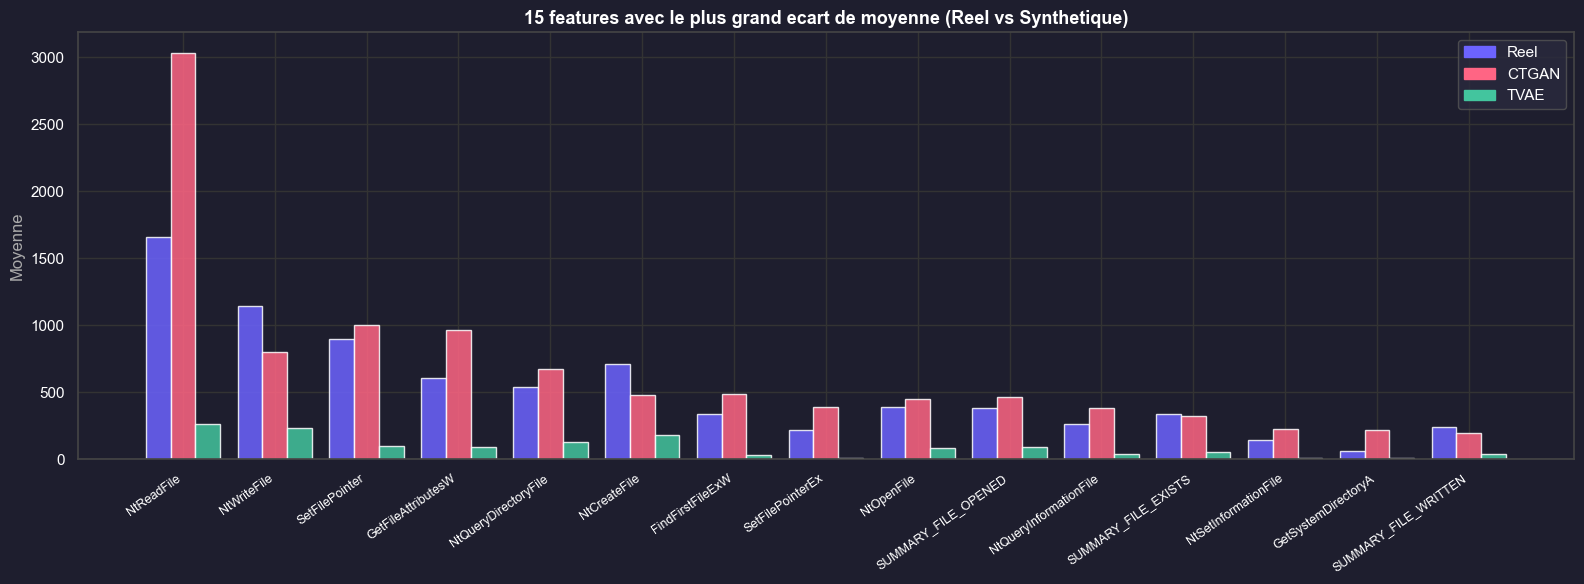

In [22]:
# ---- 3. Moyennes des top features par dataset ----
feat_cols = [c for c in real_df.columns if c != 'Label']
means = pd.DataFrame({
    'Reel' : real_df [feat_cols].mean(),
    'CTGAN': ctgan_df[feat_cols].mean(),
    'TVAE' : tvae_df [feat_cols].mean(),
})

# Afficher seulement les 15 features avec la plus grande variance entre datasets
spread = (means.max(axis=1) - means.min(axis=1))
top15  = spread.nlargest(15).index
means15 = means.loc[top15]

x     = np.arange(len(top15))
width = 0.27

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

ax.bar(x - width, means15['Reel'],  width, label='Reel',  color=CLR_REAL,  alpha=0.85)
ax.bar(x,         means15['CTGAN'], width, label='CTGAN', color=CLR_CTGAN, alpha=0.85)
ax.bar(x + width, means15['TVAE'],  width, label='TVAE',  color=CLR_TVAE,  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top15, rotation=35, ha='right', fontsize=9)
ax.tick_params(colors='white')
ax.set_ylabel('Moyenne', color='#aaa')
ax.set_title('15 features avec le plus grand ecart de moyenne (Reel vs Synthetique)',
             fontsize=13, fontweight='bold')
for sp in ax.spines.values(): sp.set_edgecolor('#444')
ax.legend(handles=handles, facecolor='#2a2a3e', edgecolor='#555', labelcolor='white')

plt.tight_layout()
plt.show()


<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">VIZ 4</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Resume statistique</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Moyenne et ecart-type par dataset pour toutes les features.</p>
</div>


In [23]:
# ---- 4. Resume statistique (mean / std) sur toutes les features ----
feat_cols = [c for c in real_df.columns if c != 'Label']

summary = pd.DataFrame({
    'Reel  mean' : real_df [feat_cols].mean().round(2),
    'CTGAN mean' : ctgan_df[feat_cols].mean().round(2),
    'TVAE  mean' : tvae_df [feat_cols].mean().round(2),
    'Reel  std'  : real_df [feat_cols].std().round(2),
    'CTGAN std'  : ctgan_df[feat_cols].std().round(2),
    'TVAE  std'  : tvae_df [feat_cols].std().round(2),
})
print('--- Resume mean / std (10 premieres features) ---')
print(summary.head(10).to_string())


--- Resume mean / std (10 premieres features) ---
                              Reel  mean  CTGAN mean  TVAE  mean  Reel  std  CTGAN std  TVAE  std
CopyFileA                           0.06        0.02        0.00       0.29       0.20       0.00
CopyFileW                           0.31        0.03        0.00       1.51       0.37       0.00
CreateDirectoryW                   26.82       45.39       10.28      70.87      99.01      38.88
DeleteFileW                        19.16       24.02        2.69      88.28     102.79       4.68
DeviceIoControl                     8.86        3.44        2.40      31.36      16.08       4.69
FindFirstFileExW                  336.43      487.77       34.70    1204.74    1342.20      44.57
GetFileAttributesExW               49.84       50.11        6.72     233.24     269.56       6.71
GetFileAttributesW                602.56      966.92       94.30    1591.26    2024.67     412.19
GetFileInformationByHandle          1.45        0.78        0.37    

<div style="background:#2a2a3e;border-left:4px solid #FF6584;border-radius:5px;padding:13px 18px;margin:10px 0 8px 0;font-family:'Segoe UI',sans-serif;">
  <span style="display:inline-block;background:#FF6584;color:white;font-size:10px;font-weight:700;padding:1px 8px;border-radius:20px;letter-spacing:1px;margin-bottom:6px;">VIZ 5</span>
  <h3 style="margin:0;font-size:16px;color:#e0e0f0;font-weight:600;">Difference de matrices de correlation</h3>
  <p style="margin:5px 0 0 0;font-size:12.5px;color:#aaaacc;">Carte de chaleur de l'ecart absolu entre les correlations reelles et synthetiques.</p>
</div>


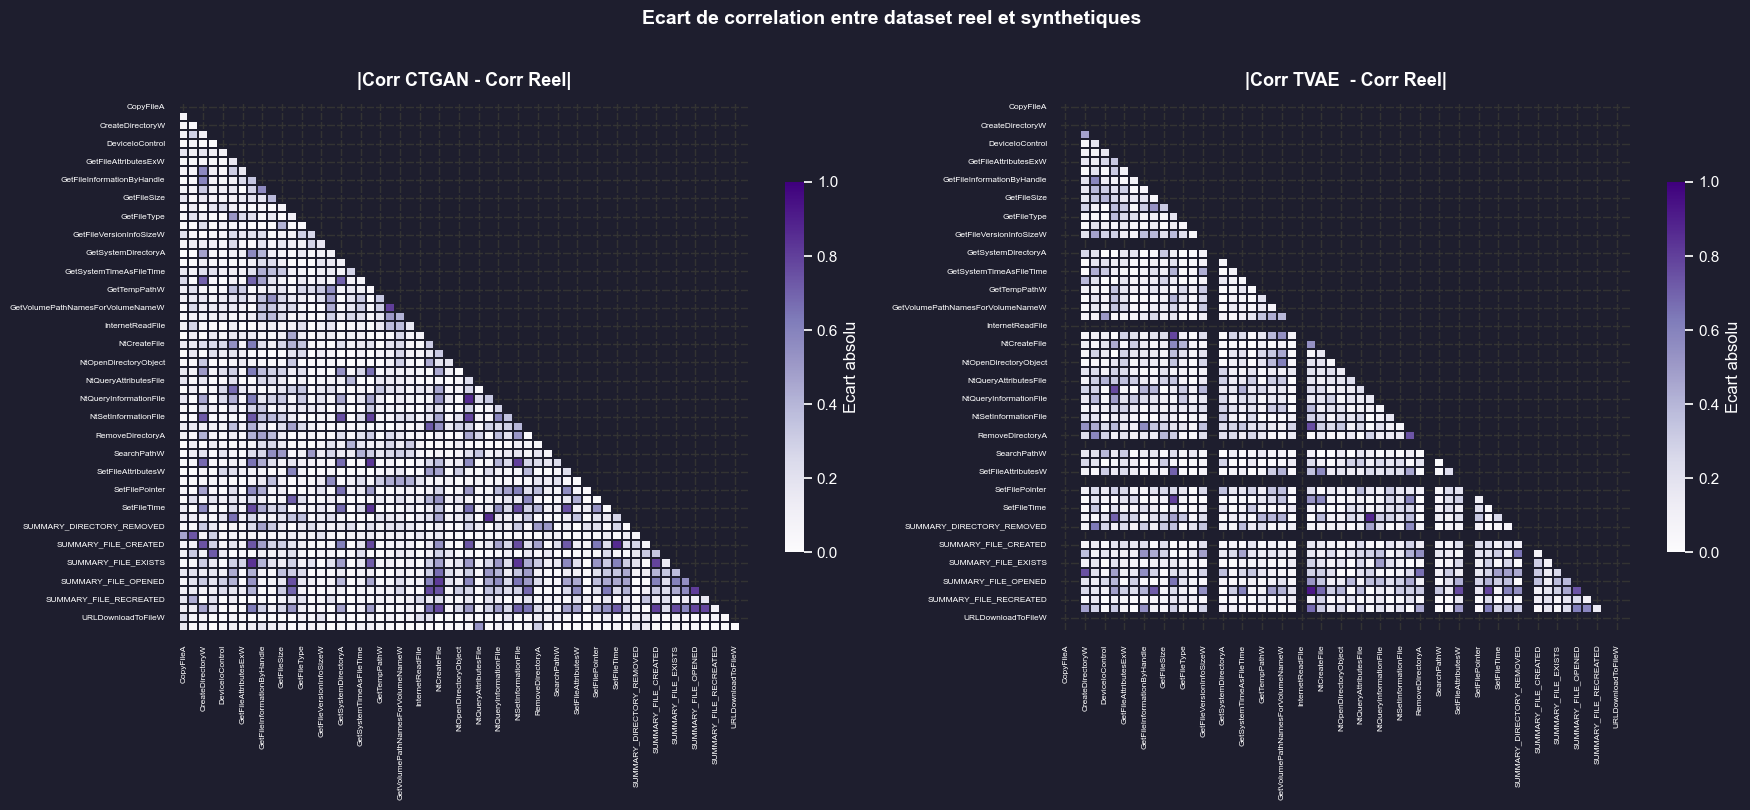

In [24]:
# ---- 5. Difference de matrice de correlation (CTGAN - Reel) et (TVAE - Reel) ----
feat_cols = [c for c in real_df.columns if c != 'Label']

corr_real  = real_df [feat_cols].corr()
corr_ctgan = ctgan_df[feat_cols].corr()
corr_tvae  = tvae_df [feat_cols].corr()

diff_ctgan = (corr_ctgan - corr_real).abs()
diff_tvae  = (corr_tvae  - corr_real).abs()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(DARK_BG)

for ax, diff, title in [
    (axes[0], diff_ctgan, '|Corr CTGAN - Corr Reel|'),
    (axes[1], diff_tvae,  '|Corr TVAE  - Corr Reel|'),
]:
    ax.set_facecolor(DARK_BG)
    mask = np.triu(np.ones_like(diff, dtype=bool))
    sns.heatmap(diff, mask=mask, cmap='Purples', vmin=0, vmax=1,
                annot=False, linewidths=0.2, linecolor=DARK_BG,
                ax=ax, cbar_kws={'shrink':0.7, 'label':'Ecart absolu'})
    ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=12)
    ax.tick_params(colors='white', labelsize=6)
    ax.figure.axes[-1].tick_params(colors='white')
    ax.figure.axes[-1].yaxis.label.set_color('white')

plt.suptitle('Ecart de correlation entre dataset reel et synthetiques',
             fontsize=14, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.show()
